### Advanced Programming Assignment _8
### Name: Meron Abebe
### ID No: GSR/4256/18

# Question 1: Differences among Genome Representations

- **[Linear reference genome]**  
  A single, continuous sequence chosen as the “reference.”  
  - **Pros:** Simple, widely used, efficient.  
  - **Cons:** Biased, ignores variation across individuals.  

- **[Assembly graph]**  
  Graph built during genome assembly.  
  - **Nodes:** sequence fragments (contigs/k-mers).  
  - **Edges:** overlaps between fragments.  
  - Captures ambiguities and repeats.  

- **[Variation graph]**  
  Graph encoding genetic variation relative to a reference.  
  - **Nodes:** sequence segments.  
  - **Edges:** alternative alleles.  
  - Used in tools like VG for mapping reads across variants.  

- **[Genome graph]**  
  General term for graph-based representation of genomes.  
  - Can include variation, repeats, structural differences.  
  - More flexible than linear references.  

- **[Pangenome graph]**  
  Graph combining multiple genomes of a species.  
  - Shows **core regions** (shared) and **accessory regions** (variable).  
  - Useful for population-scale analysis and evolutionary studies.  


# Question 2: BFS and DFS in Graph-Based Genomic Analysis

- **[Breadth-First Search (BFS)**  
  - Explores the graph level by level.  
  - Useful for finding **shortest paths** in genome graphs.  
  - Helps identify **connected components** and explore variation systematically.  
  - Example application: detecting shared haplotypes across individuals by traversing variation graphs.

- **[Depth-First Search (DFS)]**  
  - Explores deeply along one path before backtracking.  
  - Useful for **path enumeration** and **motif discovery**.  
  - Helps reconstruct **haplotypes** by following alternative allelic paths.  
  - Example application: exploring all possible genome assembly paths in an **assembly graph**.

  
Both BFS and DFS are essential for analyzing graph-based genomic structures. BFS is better for systematic exploration and shortest path detection, while DFS is better for deep exploration, path reconstruction, and motif discovery.


# Question 3: Linear vs Graph-Based Reference Genomes

- [Linear reference genome]  
  - Represents the genome as a single, continuous sequence.  
  - **Advantages:**  
    - Simple and widely adopted in bioinformatics pipelines.  
    - Efficient for alignment and variant calling.  
  - **Limitations:**  
    - Biased toward the chosen reference individual.  
    - Misses structural variations, insertions, and population diversity.  

- **[Graph-based reference genome]  
  - Represents the genome as a graph structure, where nodes are sequence segments and edges represent possible connections (including variants).  
  - **Advantages:**  
    - Captures genetic variation across populations.  
    - Supports multiple haplotypes and structural differences.  
    - Reduces reference bias in read mapping.  
  - **Limitations:**  
    - Computationally more complex.  
    - Requires specialized tools and algorithms.  

**Summary:**  
Linear references are simple but limited, while graph-based references provide a richer, more accurate representation of genetic diversity. Graph-based approaches are increasingly important in [pangenomics and population-scale studies.


# Question 4: Construct a De Bruijn Graph (k=3)

**Reads:** ATGC, TGCA, GCAT, CATG



### 1. [List all 3-mers]
- ATG  
- TGC  
- GCA  
- CAT  



### 2. [Identify all 2-mer nodes]
- AT  
- TG  
- GC  
- CA  



### 3. Directed De Bruijn Graph
Edges are formed by prefix → suffix of each 3-mer:
- AT → TG  
- TG → GC  
- GC → CA  
- CA → AT  



### 4. [Calculate in-degree and out-degree]
- AT: in = 1, out = 1  
- TG: in = 1, out = 1  
- GC: in = 1, out = 1  
- CA: in = 1, out = 1  



### 5. Eulerian Path or Cycle
- All nodes are balanced (in-degree = out-degree).  
- Therefore, an **Eulerian cycle** exists.  



### 6. [Reconstruct the sequence]
- Traversing the cycle gives: **ATGCATG** (cyclic sequence).  

In [1]:

from collections import defaultdict

# Reads and k-mer size
reads = ["ATGC","TGCA","GCAT","CATG"]
k = 3

# Step 1: Generate k-mers
kmers = [read[i:i+k] for read in reads for i in range(len(read)-k+1)]
print("3-mers:", kmers)

# Step 2: Identify nodes (prefix and suffix of k-mers)
nodes = set([kmer[:-1] for kmer in kmers] + [kmer[1:] for kmer in kmers])
print("Nodes:", nodes)

# Step 3: Build edges
edges = [(kmer[:-1], kmer[1:]) for kmer in kmers]
print("Edges:", edges)

# Step 4: Calculate in-degree and out-degree
in_degree = defaultdict(int)
out_degree = defaultdict(int)
for u,v in edges:
    out_degree[u] += 1
    in_degree[v] += 1

print("In-degree:", dict(in_degree))
print("Out-degree:", dict(out_degree))

# Step 5: Check Eulerian cycle
balanced = all(in_degree[node] == out_degree[node] for node in nodes)
print("Eulerian cycle exists:", balanced)

# Step 6: Reconstruct sequence (simple traversal)
sequence = kmers[0]
for kmer in kmers[1:]:
    sequence += kmer[-1]
print("Reconstructed sequence:", sequence)


3-mers: ['ATG', 'TGC', 'TGC', 'GCA', 'GCA', 'CAT', 'CAT', 'ATG']
Nodes: {'GC', 'TG', 'CA', 'AT'}
Edges: [('AT', 'TG'), ('TG', 'GC'), ('TG', 'GC'), ('GC', 'CA'), ('GC', 'CA'), ('CA', 'AT'), ('CA', 'AT'), ('AT', 'TG')]
In-degree: {'TG': 2, 'GC': 2, 'CA': 2, 'AT': 2}
Out-degree: {'AT': 2, 'TG': 2, 'GC': 2, 'CA': 2}
Eulerian cycle exists: True
Reconstructed sequence: ATGCCAATTG


# Question 5: Construct a Pangenome Graph

**Genomes:**
- Genome 1: ACTGAC  
- Genome 2: ACTAAC  
- Genome 3: ACTGGAC  



### 1. [Identify shared sequence regions]
- All genomes share the prefix **ACT** and suffix **AC**.  


### 2. [Identify the SNP]
- At position 4:  
  - Genome 1 → G  
  - Genome 2 → A  
  - Genome 3 → G  
- SNP = **A ↔ G**.  



### 3. [Identify the insertion]
- Genome 3 has an extra **G** before the final AC.  
- Insertion = **G**.  



### 4. Graph Representation
- Start with **ACT**.  
- Branch at position 4: **A** or **G**.  
- If **G**, Genome 3 continues with an extra **G** before rejoining at **AC**.  
- All paths rejoin at **AC**.  



### 5. [Write each genome as a path]
- Genome 1: ACT → G → AC  
- Genome 2: ACT → A → AC  
- Genome 3: ACT → G → G → AC  



### 6. [Identify branch and rejoining nodes]
- Branch node: after **ACT**.  
- Rejoining node: before **AC**.  



### 7. [Classify graph segments]
- **Core:** ACT, AC  
- **Accessory:** A, G (SNP variants)  
- **Unique:** Extra G (insertion in Genome 3)  





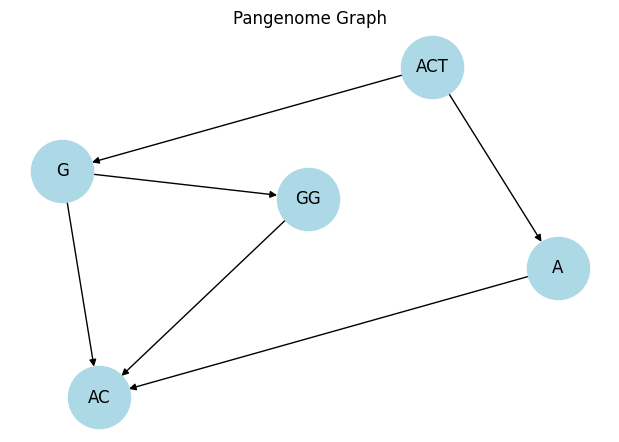

In [2]:
## Python Visualization 


import networkx as nx
import matplotlib.pyplot as plt

# Define graph edges for the pangenome
edges = [
    ("ACT", "A"), ("A", "AC"),          # Genome 2
    ("ACT", "G"), ("G", "AC"),          # Genome 1
    ("ACT", "G"), ("G", "GG"), ("GG", "AC")  # Genome 3 with insertion
]

G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000, arrows=True)
plt.title("Pangenome Graph")
plt.show()


# Question 6: Graph Traversal

**Graph:**
- A → B → D  
- A → C → D  
- C → E → F  



### 1. [Perform BFS from A](ca://s?q=Perform_BFS_from_A)
- Order: A, B, C, D, E, F  



### 2. [Perform DFS from A](ca://s?q=Perform_DFS_from_A)
- Order: A, B, D, C, E, F  



### 3. [List all paths from A to D](ca://s?q=List_all_paths_from_A_to_D)
- Path 1: A → B → D  
- Path 2: A → C → D  



### 4. [Identify branching nodes](ca://s?q=Identify_branching_nodes)
- **A** (branches to B and C)  
- **C** (branches to D and E)  



### 5. [Determine whether the graph is acyclic](ca://s?q=Determine_if_graph_is_acyclic)
- No cycles present → Graph is **acyclic**.  

In [4]:

from collections import deque

# Define the graph
graph = {
    "A": ["B","C"],
    "B": ["D"],
    "C": ["D","E"],
    "D": [],
    "E": ["F"],
    "F": []
}

# BFS
def bfs(start):
    visited, queue = set([start]), deque([start])
    order = []
    while queue:
        node = queue.popleft()
        order.append(node)
        for neigh in graph[node]:
            if neigh not in visited:
                visited.add(neigh)
                queue.append(neigh)
    return order

# DFS
def dfs(start, visited=None, order=None):
    if visited is None: visited=set()
    if order is None: order=[]
    visited.add(start)
    order.append(start)
    for neigh in graph[start]:
        if neigh not in visited:
            dfs(neigh, visited, order)
    return order

# Find all paths from A to D
def all_paths(start, end, path=None):
    if path is None: path=[]
    path = path + [start]
    if start == end:
        return [path]
    if start not in graph:
        return []
    paths = []
    for node in graph[start]:
        if node not in path:
            newpaths = all_paths(node, end, path)
            for p in newpaths:
                paths.append(p)
    return paths

print("BFS from A:", bfs("A"))
print("DFS from A:", dfs("A"))
print("Paths from A to D:", all_paths("A","D"))

BFS from A: ['A', 'B', 'C', 'D', 'E', 'F']
DFS from A: ['A', 'B', 'D', 'C', 'E', 'F']
Paths from A to D: [['A', 'B', 'D'], ['A', 'C', 'D']]
